#### The Two Primary MethodsPower transformers rely on parameterized mathematical transformations, finding an optimal power parameter $\lambda$ (lambda) via maximum likelihood estimation to maximize normality.
### two main ones are :
### BOX-COX :
####    used for strictly positive values (y > 0). Fails on zero or negative numbers.Purely positive continuous features like price, volume, or distance.

### Yeo - Jhonson:
####    Supports zero and negative numbers .General datasets containing zeros, negative values, or mixed signs.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import LinearRegression

In [3]:
data = pd.read_csv(r"C:\Users\pc\Downloads\concrete_data.csv")
data.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


<Axes: xlabel='Superplasticizer', ylabel='Count'>

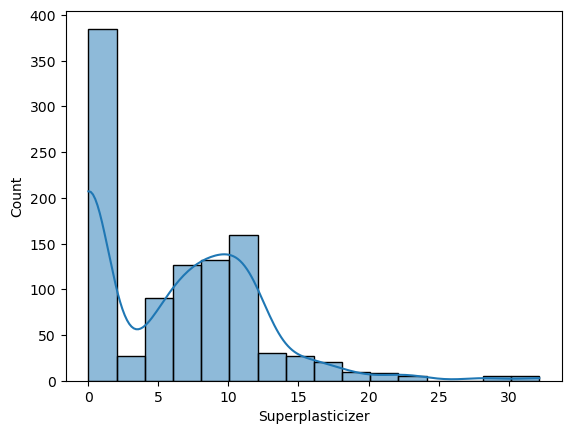

In [5]:
sns.histplot(data['Superplasticizer'],kde = True)

In [6]:
pt = PowerTransformer(method='box-cox')
X = data[['Superplasticizer']] + 0.0000001
transformed = pt.fit_transform(X)
transformed

array([[ 0.48597298],
       [ 0.48597298],
       [-1.30627303],
       ...,
       [ 0.67429684],
       [ 0.81336349],
       [ 0.75084317]], shape=(1030, 1))

<Axes: ylabel='Count'>

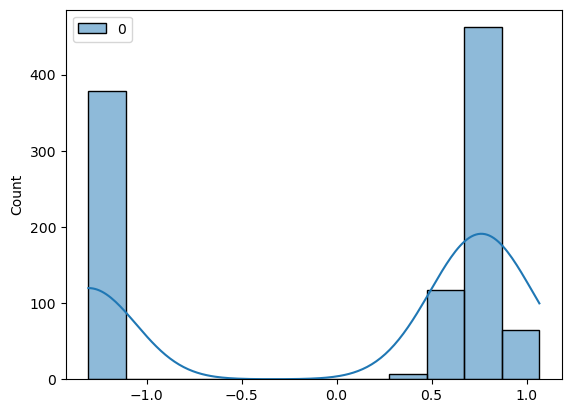

In [7]:
sns.histplot(transformed,kde = True)

In [8]:
pt = PowerTransformer(method='yeo-johnson')
X = data[['Superplasticizer']]
y_transformed = pt.fit_transform(X)
y_transformed

array([[-0.32769999],
       [-0.32769999],
       [-1.22581532],
       ...,
       [ 0.32719602],
       [ 0.92749035],
       [ 0.64593861]], shape=(1030, 1))

<Axes: ylabel='Count'>

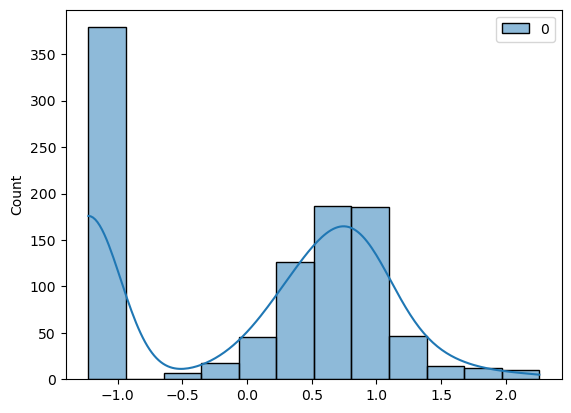

In [9]:
sns.histplot(y_transformed,kde = True)

In [10]:
print(pt.lambdas_)

[0.26416021]
